## tl;dr

This notebook evaluates the recorded generated-plus-real CRNN augmentation
study. Validation selected 200 generated spectrograms per species for both
VAE-v3 and diffusion. On the selected ratios, VAE-v3 reached 89.48% mean test
macro F1 and diffusion reached 89.28%, below the historical selected CRNN
reference of 90.16%.

These are descriptive results, not a causal estimate: the baseline is one
historical seed trained through a different input pipeline and there is no
matched cached-real-only control.


## Context & Methods

The study mixes fixed generated spectrogram rows into the full real training
set; it does not implement the MixUp interpolation algorithm. The tracked
report contains 18 validation runs: two generators, ratios 50/100/200 per
species, and seeds 42/123/777. Only the validation-selected ratio for each
generator was evaluated on the 489-clip test manifest.

### Key Assumptions

- The tracked report package is the portable source of truth.
- Historical provenance paths shown inside the report are not operational
  paths for this reorganized checkout.
- The recorded selection rule is preserved; this notebook does not reselect
  ratios using newer code or test results.


## Data


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
REPORT_ROOT = PROJECT_ROOT / "reports" / "crnn_synthetic_augmentation_2026-08-09"
LOCAL_RUN_ROOT = PROJECT_ROOT / "runs" / "crnn_synthetic_augmentation" / "cache_sweep"
INCLUDE_LOCAL_RUN_DETAILS = False

summary_payload = json.loads((REPORT_ROOT / "summary.json").read_text(encoding="utf-8"))
protocol_payload = json.loads((REPORT_ROOT / "protocol.json").read_text(encoding="utf-8"))
validation_summary = pd.read_csv(REPORT_ROOT / "validation_summary.csv")
test_summary = pd.read_csv(REPORT_ROOT / "test_summary.csv")

required_validation_columns = {
    "generator", "ratio_per_species", "seed", "best_validation_macro_f1",
    "mean_macro_f1_across_seeds", "selected_for_test",
}
required_test_columns = {
    "scope", "condition", "generator", "ratio_per_species", "seed",
    "accuracy", "macro_f1", "delta_accuracy_vs_historical",
    "delta_macro_f1_vs_historical",
}
assert required_validation_columns.issubset(validation_summary.columns)
assert required_test_columns.issubset(test_summary.columns)
assert len(validation_summary) == 18
assert validation_summary["seed"].nunique() == 3
assert set(validation_summary["generator"]) == {"vae_v3", "diffusion"}
assert set(validation_summary["ratio_per_species"]) == {50, 100, 200}
assert set(test_summary["scope"]) == {"historical_reference", "seed", "three_seed_mean"}
for generator in ("vae_v3", "diffusion"):
    recorded_mean = summary_payload["test_results"][generator]["mean_macro_f1"]
    table_mean = float(test_summary[
        (test_summary["scope"] == "three_seed_mean") & (test_summary["generator"] == generator)
    ].iloc[0]["macro_f1"])
    assert np.isclose(recorded_mean, table_mean, atol=1e-12)

print("Report:", REPORT_ROOT)
print("Question:", protocol_payload["task"])
print("Validation rows:", len(validation_summary))
print("Test rows:", len(test_summary))


Report: C:\Users\Harvey\Documents\Coding\bird_song_gen\reports\crnn_synthetic_augmentation_2026-08-09
Question: Evaluate whether adding fixed VAE-v3 or diffusion spectrogram pools improves a three-species CRNN.
Validation rows: 18
Test rows: 9


In [2]:
condition_rows = []
real_rows = protocol_payload["data_splits"]["train"]["clips"]
for ratio in protocol_payload["augmentation_conditions"]["ratios_per_species"]:
    generated_rows = ratio * 3
    condition_rows.append({
        "ratio_per_species": ratio,
        "real_rows": real_rows,
        "generated_rows": generated_rows,
        "train_rows": real_rows + generated_rows,
        "synthetic_row_share": generated_rows / (real_rows + generated_rows),
    })
condition_table = pd.DataFrame(condition_rows)
display(condition_table.style.format({"synthetic_row_share": "{:.2%}"}))


,ratio_per_species,real_rows,generated_rows,train_rows,synthetic_row_share
0,50,2339,150,2489,6.03%
1,100,2339,300,2639,11.37%
2,200,2339,600,2939,20.42%


## Results


### Validation ratio selection


,generator,ratio_per_species,mean,sample_sd,runs,recorded_mean
0,diffusion,50,87.25%,1.59%,3,87.25%
1,diffusion,100,89.00%,0.69%,3,89.00%
2,diffusion,200,89.32%,1.88%,3,89.32%
3,vae_v3,50,88.73%,1.50%,3,88.73%
4,vae_v3,100,88.15%,1.41%,3,88.15%
5,vae_v3,200,89.23%,1.62%,3,89.23%


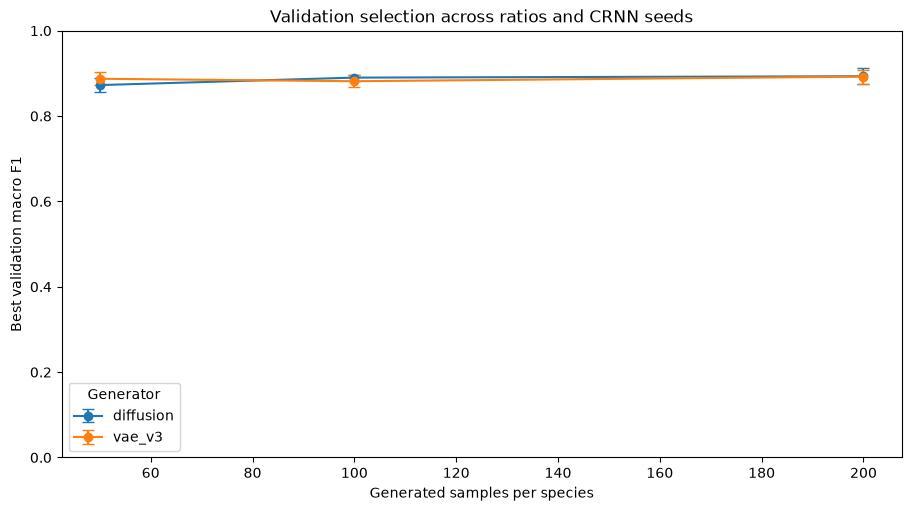

In [3]:
validation_grouped = (
    validation_summary
    .groupby(["generator", "ratio_per_species"])["best_validation_macro_f1"]
    .agg(mean="mean", sample_sd="std", runs="count")
    .reset_index()
)
recorded_means = (
    validation_summary
    .groupby(["generator", "ratio_per_species"])["mean_macro_f1_across_seeds"]
    .first()
    .reset_index(name="recorded_mean")
)
validation_grouped = validation_grouped.merge(recorded_means, on=["generator", "ratio_per_species"])
assert np.allclose(validation_grouped["mean"], validation_grouped["recorded_mean"], atol=1e-12)
display(validation_grouped.style.format({
    "mean": "{:.2%}",
    "sample_sd": "{:.2%}",
    "recorded_mean": "{:.2%}",
}))

fig, axis = plt.subplots(figsize=(9, 5), constrained_layout=True)
for generator, frame in validation_grouped.groupby("generator"):
    axis.errorbar(
        frame["ratio_per_species"],
        frame["mean"],
        yerr=frame["sample_sd"],
        marker="o",
        capsize=4,
        label=generator,
    )
axis.set(
    xlabel="Generated samples per species",
    ylabel="Best validation macro F1",
    ylim=(0, 1),
    title="Validation selection across ratios and CRNN seeds",
)
axis.legend(title="Generator")
plt.show()


### Selected-ratio held-out results


In [4]:
selected_rows = validation_summary[validation_summary["selected_for_test"].astype(str).str.lower() == "true"]
selected_counts = selected_rows.groupby("generator")["ratio_per_species"].nunique()
assert selected_counts.to_dict() == {"vae_v3": 1, "diffusion": 1}
assert set(selected_rows["ratio_per_species"]) == {200}
selection_table = (
    selected_rows
    .groupby(["generator", "ratio_per_species"])["best_validation_macro_f1"]
    .agg(mean="mean", sample_sd="std")
    .reset_index()
)
display(selection_table.style.format({"mean": "{:.2%}", "sample_sd": "{:.2%}"}))
print("Recorded selected ratio: 200 generated samples per species for both generators.")


,generator,ratio_per_species,mean,sample_sd
0,diffusion,200,89.32%,1.88%
1,vae_v3,200,89.23%,1.62%


Recorded selected ratio: 200 generated samples per species for both generators.


,generator,ratio_per_species,mean,sample_sd,runs
0,diffusion,200,89.28%,1.51%,3
1,vae_v3,200,89.48%,2.76%,3


,condition,generator,ratio_per_species,accuracy,macro_f1,delta_accuracy_vs_historical,delta_macro_f1_vs_historical
4,vae_v3_augmented,vae_v3,200,89.43%,89.48%,-0.55%,-0.68%
8,diffusion_augmented,diffusion,200,89.23%,89.28%,-0.75%,-0.88%


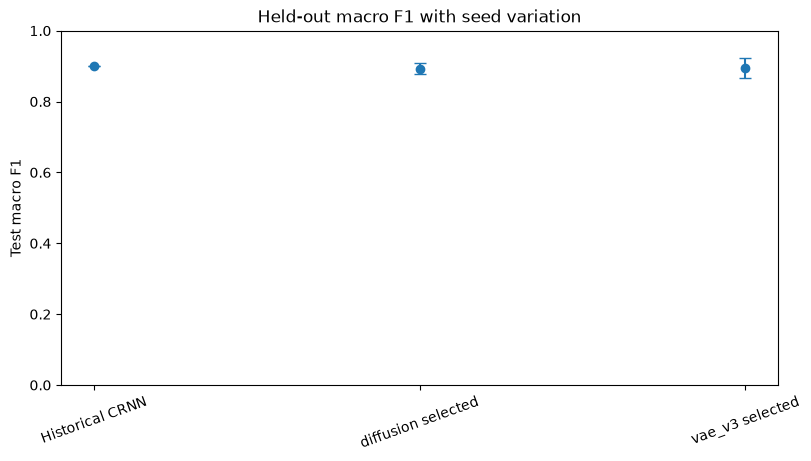

In [5]:
test_seed_rows = test_summary[test_summary["scope"] == "seed"].copy()
test_mean_rows = test_summary[test_summary["scope"] == "three_seed_mean"].copy()
historical_row = test_summary[test_summary["scope"] == "historical_reference"].iloc[0]
test_grouped = (
    test_seed_rows
    .groupby(["generator", "ratio_per_species"])["macro_f1"]
    .agg(mean="mean", sample_sd="std", runs="count")
    .reset_index()
)
display(test_grouped.style.format({"mean": "{:.2%}", "sample_sd": "{:.2%}"}))
display(test_mean_rows[[
    "condition", "generator", "ratio_per_species", "accuracy", "macro_f1",
    "delta_accuracy_vs_historical", "delta_macro_f1_vs_historical",
]].style.format({
    "accuracy": "{:.2%}",
    "macro_f1": "{:.2%}",
    "delta_accuracy_vs_historical": "{:+.2%}",
    "delta_macro_f1_vs_historical": "{:+.2%}",
}))

plot_rows = pd.concat([
    pd.DataFrame([{
        "condition": "Historical CRNN",
        "generator": "historical",
        "macro_f1": historical_row["macro_f1"],
        "sample_sd": 0.0,
    }]),
    test_grouped.rename(columns={"mean": "macro_f1"})[["generator", "macro_f1", "sample_sd"]]
    .assign(condition=lambda frame: frame["generator"] + " selected"),
], ignore_index=True)
fig, axis = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
positions = np.arange(len(plot_rows))
axis.errorbar(
    positions,
    plot_rows["macro_f1"],
    yerr=plot_rows["sample_sd"],
    fmt="o",
    capsize=4,
)
axis.set(
    xticks=positions,
    xticklabels=plot_rows["condition"],
    ylabel="Test macro F1",
    ylim=(0, 1),
    title="Held-out macro F1 with seed variation",
)
axis.tick_params(axis="x", rotation=20)
plt.show()


### Species recall


In [6]:
recall_columns = [
    "recall_american_robin",
    "recall_northern_cardinal",
    "recall_song_sparrow",
]
recall_rows = [{
    "condition": "Historical CRNN",
    **{column: float(historical_row[column]) for column in recall_columns},
}]
for generator, frame in test_seed_rows.groupby("generator"):
    recall_rows.append({
        "condition": f"{generator} selected mean",
        **{column: float(frame[column].mean()) for column in recall_columns},
    })
recall_table = pd.DataFrame(recall_rows)
display(recall_table.style.format({column: "{:.2%}" for column in recall_columns}))


,condition,recall_american_robin,recall_northern_cardinal,recall_song_sparrow
0,Historical CRNN,95.17%,85.80%,89.56%
1,diffusion selected mean,94.71%,78.60%,94.32%
2,vae_v3 selected mean,93.10%,88.68%,87.18%


### Optional local run details


In [7]:
if not INCLUDE_LOCAL_RUN_DETAILS:
    print("Local learning-curve details are disabled; tracked report tables remain the primary analysis.")
else:
    history_paths = sorted(LOCAL_RUN_ROOT.glob("*/*/seed_*/history.json"))
    if not history_paths:
        print("No ignored local histories found at:", LOCAL_RUN_ROOT)
    else:
        scalar_rows = []
        for history_path in history_paths:
            relative_parts = history_path.relative_to(LOCAL_RUN_ROOT).parts
            generator, ratio_name, seed_name = relative_parts[:3]
            history_payload = json.loads(history_path.read_text(encoding="utf-8"))
            for entry in history_payload:
                validation = entry.get("validation", {})
                scalar_rows.append({
                    "generator": generator,
                    "ratio_per_species": int(ratio_name.replace("ratio_", "")),
                    "seed": int(seed_name.replace("seed_", "")),
                    "step": entry["step"],
                    "validation_macro_f1": validation.get("macro_f1"),
                    "validation_accuracy": validation.get("accuracy"),
                })
        local_history = pd.DataFrame(scalar_rows)
        display(local_history.head())
        print("Loaded local history files:", len(history_paths))


Local learning-curve details are disabled; tracked report tables remain the primary analysis.


## Takeaways

Both generators selected 200 generated samples per species. VAE-v3 achieved
89.48% mean test macro F1 and diffusion achieved 89.28%, compared with 90.16%
for the historical selected CRNN. The supported statement is that neither
selected arm demonstrated a mean held-out gain in this first evaluation.

This does not establish that generated data harms performance. The reference is
one seed trained through the earlier WAV pipeline, the augmented arms use
three seeds and fixed cached real spectrograms, no matched cached-real-only
control was recorded, and only one generated-pool seed was tested. The
historical validation split also contains nine exact train duplicates, though
none reaches test.
